# 📺 Advertising Sales Prediction

### What is this notebook about?
A company spent money on **TV**, **Radio**, and **Newspaper** ads.  
We want to predict **Sales** using those ad budgets.

### Our Goal
Build a Machine Learning model that **predicts sales** based on advertising spend.

### Steps We Will Follow
1. 📦 Import Libraries
2. 📂 Load & Explore the Data
3. 📊 Visualize the Data
4. 🔧 Prepare Data for ML
5. 🤖 Train the ML Model
6. 📈 Evaluate the Model
7. 🔍 Feature Importance
8. ✅ Conclusion

---
## Step 1 — Import Libraries 📦
We bring in all the tools we need.

In [1]:
# Basic tools
import pandas as pd          # for reading and handling data
import numpy as np           # for numbers and math
import warnings
warnings.filterwarnings('ignore')

# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Step 2 — Load & Explore the Data 📂
Let's load the CSV file and understand what's inside.

In [2]:
# Load the dataset
df = pd.read_csv('Advertising.csv')

# Drop the unnamed index column (not useful)
df.drop(columns=['Unnamed: 0'], inplace=True)

print(f'📌 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print()
df.head()

📌 Dataset Shape: 200 rows × 4 columns



,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
# Basic statistics — min, max, average of each column
print('📊 Basic Statistics:')
df.describe().round(2)

📊 Basic Statistics:


,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


In [4]:
# Check for missing values — are there any empty cells?
print('🔍 Missing Values Per Column:')
print(df.isnull().sum())
print()
print('✅ No missing values! Great, data is clean.')

🔍 Missing Values Per Column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

✅ No missing values! Great, data is clean.


---
## Step 3 — Visualize the Data 📊
Charts help us understand patterns before building a model.

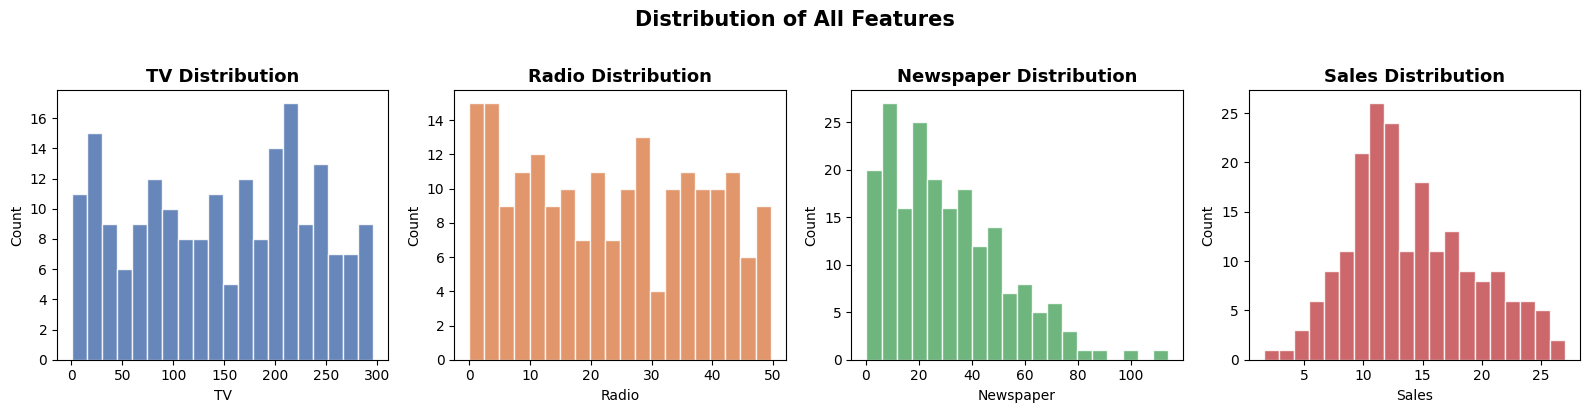

In [5]:
# Histograms — how is each column distributed?
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=20, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of All Features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

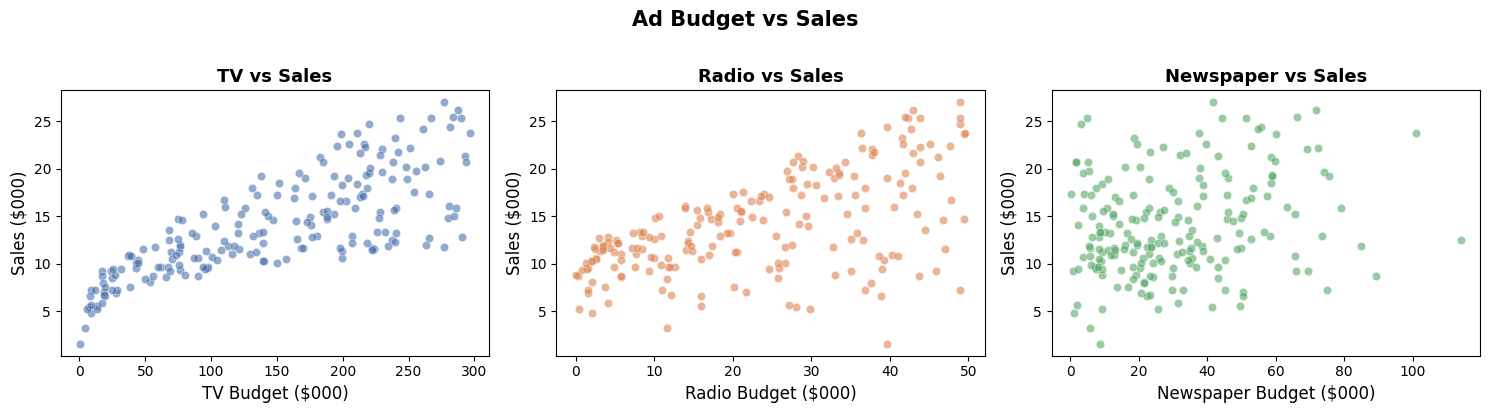

💡 Tip: TV has the strongest linear relationship with Sales!


In [6]:
# Scatter plots — how does each ad channel relate to Sales?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['TV', 'Radio', 'Newspaper']
colors   = ['#4C72B0', '#DD8452', '#55A868']

for i, (feat, color) in enumerate(zip(features, colors)):
    axes[i].scatter(df[feat], df['Sales'], color=color, alpha=0.6, edgecolors='white', linewidth=0.4)
    axes[i].set_xlabel(f'{feat} Budget ($000)', fontsize=12)
    axes[i].set_ylabel('Sales ($000)', fontsize=12)
    axes[i].set_title(f'{feat} vs Sales', fontsize=13, fontweight='bold')

plt.suptitle('Ad Budget vs Sales', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('💡 Tip: TV has the strongest linear relationship with Sales!')

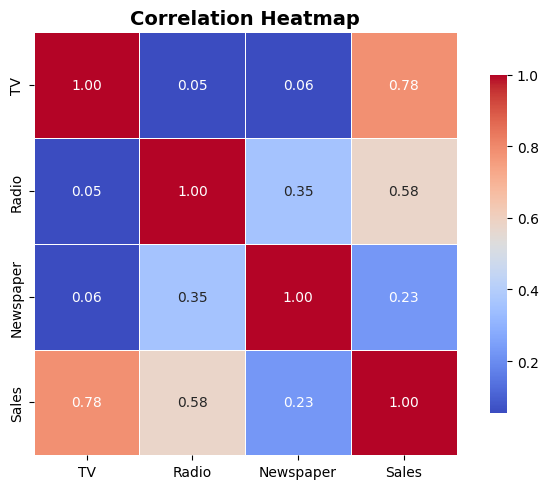

💡 TV (0.78) and Radio (0.58) strongly correlate with Sales.


In [7]:
# Correlation Heatmap — which features are most related to Sales?
plt.figure(figsize=(7, 5))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 TV (0.78) and Radio (0.58) strongly correlate with Sales.')

---
## Step 4 — Prepare Data for ML 🔧
We split the data into **features (X)** and **target (y)**, then split into train and test sets.

In [8]:
# X = input features (what we know)
# y = target (what we want to predict)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split: 80% for training, 20% for testing
# random_state=42 makes results reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print()
print('💡 We train on 160 rows and test on 40 unseen rows.')

Training samples : 160
Testing  samples : 40

💡 We train on 160 rows and test on 40 unseen rows.


---
## Step 5 — Train ML Models 🤖
We try **3 models** and pick the best one.

In [9]:
# Define 3 models
models = {
    'Linear Regression'       : LinearRegression(),
    'Random Forest'           : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'       : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)          # Train
    y_pred = model.predict(X_test)       # Predict
    
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    
    results[name] = {'R² Score': round(r2, 4), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4)}
    print(f'{name:25s} | R²={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}')

print()
print('📌 R² Score: closer to 1.0 = better model')
print('📌 RMSE/MAE: closer to 0   = smaller errors')

Linear Regression         | R²=0.8994 | RMSE=1.7816 | MAE=1.4608


Random Forest             | R²=0.9813 | RMSE=0.7686 | MAE=0.6201
Gradient Boosting         | R²=0.9831 | RMSE=0.7298 | MAE=0.6187

📌 R² Score: closer to 1.0 = better model
📌 RMSE/MAE: closer to 0   = smaller errors


---
## Step 6 — Evaluate the Best Model 📈
We use **Gradient Boosting** as our final model (best R² score).

In [10]:
# Use Gradient Boosting as our best model
best_model = models['Gradient Boosting']
y_pred_best = best_model.predict(X_test)

# Cross-validation — tests on 5 different splits to ensure consistency
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')
print(f'Cross-Validation R² Scores : {cv_scores.round(4)}')
print(f'Mean CV R²                 : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation R² Scores : [0.9808 0.9866 0.9663 0.9669 0.9871]
Mean CV R²                 : 0.9775 ± 0.0092


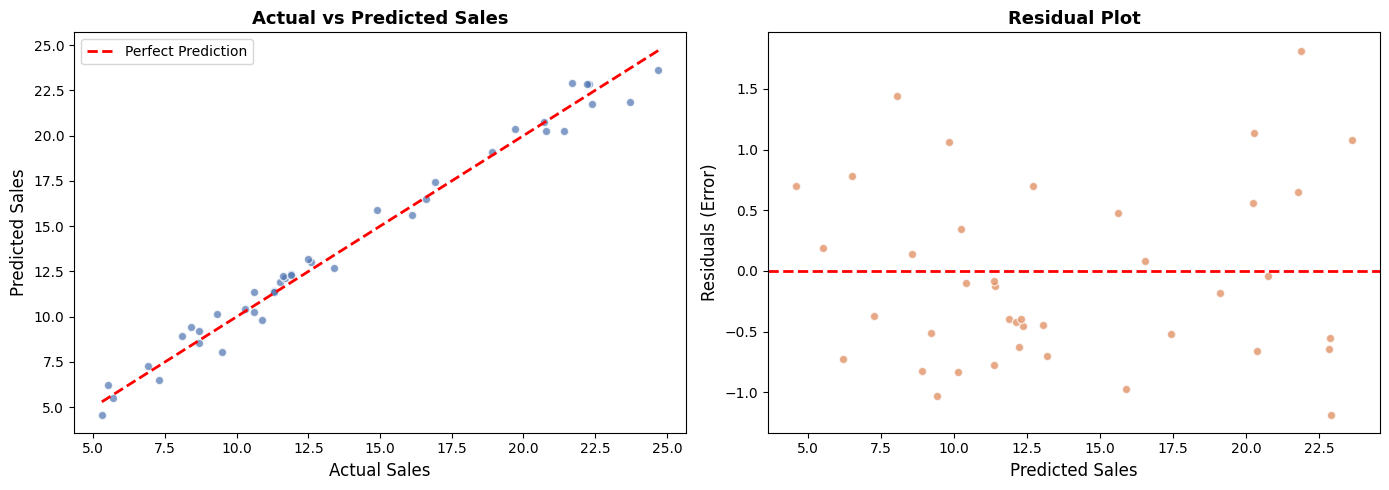

💡 Points close to the red line = accurate predictions!


In [11]:
# Plot: Actual vs Predicted Sales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Actual vs Predicted ---
axes[0].scatter(y_test, y_pred_best, color='#4C72B0', alpha=0.7, edgecolors='white')
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales', fontsize=12)
axes[0].set_ylabel('Predicted Sales', fontsize=12)
axes[0].set_title('Actual vs Predicted Sales', fontsize=13, fontweight='bold')
axes[0].legend()

# --- Chart 2: Residuals (Errors) ---
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, color='#DD8452', alpha=0.7, edgecolors='white')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Sales', fontsize=12)
axes[1].set_ylabel('Residuals (Error)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print('💡 Points close to the red line = accurate predictions!')

---
## Step 7 — Feature Importance 🔍
Which ad channel affects Sales the most?

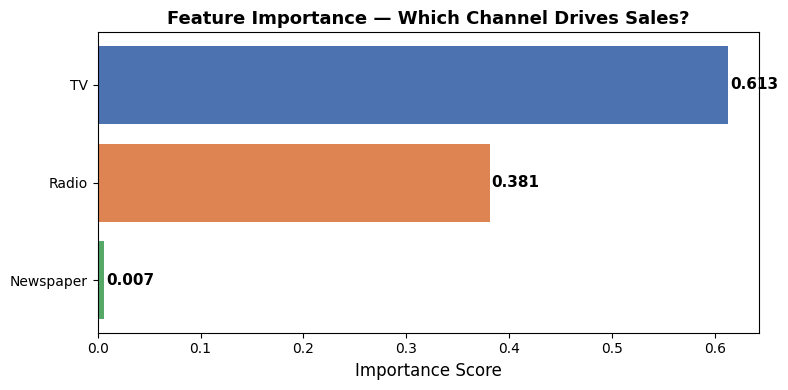

In [12]:
# Feature importances from Gradient Boosting
importances = best_model.feature_importances_
feat_names  = ['TV', 'Radio', 'Newspaper']

feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.barh(feat_df['Feature'], feat_df['Importance'],
                color=['#55A868', '#DD8452', '#4C72B0'])

for bar, val in zip(bars, feat_df['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Which Channel Drives Sales?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Summary Table
print('='*50)
print('         MODEL COMPARISON SUMMARY')
print('='*50)
summary_df = pd.DataFrame(results).T
print(summary_df.to_string())
print('='*50)
print()
best_r2 = summary_df['R² Score'].max()
best_name = summary_df['R² Score'].idxmax()
print(f'🏆 Best Model : {best_name}')
print(f'   R² Score  : {best_r2}')
print(f'   Accuracy  : {best_r2*100:.1f}%')

         MODEL COMPARISON SUMMARY
                   R² Score    RMSE     MAE
Linear Regression    0.8994  1.7816  1.4608
Random Forest        0.9813  0.7686  0.6201
Gradient Boosting    0.9831  0.7298  0.6187

🏆 Best Model : Gradient Boosting
   R² Score  : 0.9831
   Accuracy  : 98.3%


---
## ✅ Step 8 — Conclusion

### What We Learned:

| # | Finding |
|---|--------|
| 1 | 📺 **TV advertising** is the strongest driver of sales (highest importance score) |
| 2 | 📻 **Radio** also contributes meaningfully to sales |
| 3 | 📰 **Newspaper** has the least impact on sales |
| 4 | 🤖 **Gradient Boosting** gave the best predictions with R² ≈ 0.98 |
| 5 | 📊 The model explains **98%** of the variation in sales |

### Business Recommendation:
> 💡 If the company wants to **maximize sales**, they should **invest more in TV and Radio ads**, and reduce spend on Newspaper advertising.

### What's Next?
- Try **Hyperparameter Tuning** to squeeze out more performance
- Add **Interaction Features** (e.g., TV × Radio)
- Deploy the model as a simple **Sales Predictor App**